**Laboratorio de Métodos Cuantitativos Aplicados a la Gestión**

---

# **inflación argentina & Integrales**

## *De la inflación marginal mensual a la inflación acumulada*

Esta notebook acompaña el video 4 de la serie sobre integrales aplicadas al análisis económico.

**Idea central:** la inflación mensual del INDEC es una variable *marginal* (cuánto cambian los precios cada mes). Si quiero saber la inflación *acumulada* en un período, tengo que **acumular** esos cambios mensuales — que es exactamente la idea económica de integrar.

En tiempo continuo eso sería una integral; en tiempo discreto, es una sumatoria. Pero la lógica es la misma: *acumular cambios marginales para obtener el total*.

## 1. Bajamos la serie del IPC desde la API de INDEC

El INDEC publica el IPC en `apis.datos.gob.ar`. La serie que usamos es el **IPC Nivel General nacional** (base diciembre 2016 = 100).

**¿Qué es el IPC?** Es como el "precio de una canasta de consumo típica". Si el IPC vale 200, los precios son el doble que en diciembre de 2016. Si vale 12.000, son 120 veces más caros. El número solo tiene sentido *comparado con otro período* — como una temperatura: 30°C solo dice algo si lo comparás con otro momento.

> La API del gobierno a veces tiene problemas de certificado SSL, por eso usamos `verify=False` en la descarga.

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, sympy as sp
import requests, io, warnings
warnings.filterwarnings("ignore")   # silencia el aviso de SSL

# URL de la API del INDEC — IPC Nivel General nacional, base dic-2016 = 100
URL = "https://apis.datos.gob.ar/series/api/series/?limit=5000&ids=101.1_I2NG_2016_M_22&format=csv"

resp = requests.get(URL, verify=False, timeout=30)           # descarga el archivo CSV
df   = pd.read_csv(io.StringIO(resp.text), parse_dates=["indice_tiempo"])  # lo convierte en tabla
df.columns = ["fecha", "ipc"]                                # renombra las columnas
df = df.sort_values("fecha").dropna().reset_index(drop=True) # ordena y elimina filas vacías

print(f"{len(df)} meses — {df['fecha'].min().date()} a {df['fecha'].max().date()}")

120 meses — 2016-04-01 a 2026-03-01


### ¿Por qué el IPC arranca en un número raro como 100 o 12.000?

El IPC **no es un precio real** — es un número de referencia inventado para medir cambios. El INDEC eligió diciembre de 2016, le asignó el valor arbitrario **100**, y a partir de ahí todo es relativo a ese punto.

| Fecha | IPC real | ¿Qué significa? |
|---|---|---|
| Dic 2016 | 100 | punto de partida fijado por el INDEC |
| Dic 2017 | 125 | los precios subieron 25% desde el origen |
| Dic 2023 | 3.200 | los precios son 32 veces más caros que en dic-2016 |
| Mar 2026 | 12.898 | los precios son ~129 veces más caros que en dic-2016 |

El número por sí solo no dice nada. Lo que importa siempre es **comparar dos valores**: cuánto cambió el IPC entre un mes y otro.

## 2. Del IPC a la inflación mensual (la "función marginal")

**Analogía del auto:** la inflación mensual es el **velocímetro** — te dice qué tan rápido están subiendo los precios *este mes*. La inflación acumulada es el **odómetro** — te dice cuánto recorrieron los precios en total desde un punto de partida.

- Velocímetro en 5% → los precios suben a 5% por mes este mes.
- Odómetro en 300% → los precios ya recorrieron un 300% desde el origen.

La fórmula del velocímetro mensual es:

$$ \pi_t = \frac{IPC_t - IPC_{t-1}}{IPC_{t-1}} $$

La primera fila queda vacía (`NaN`) porque no hay un mes anterior contra el cual comparar.

In [11]:
ipc0 = df["ipc"].iloc[0]   # IPC del primer mes → es nuestro punto de partida (el "origen del odómetro")

# Velocímetro: cuánto subieron los precios este mes respecto al anterior
df["inflacion_mensual"]   = df["ipc"].pct_change() * 100

# Odómetro: cuánto subieron los precios en total desde el primer dato
df["inflacion_acumulada"] = (df["ipc"] / ipc0 - 1) * 100

df[["fecha", "inflacion_mensual", "inflacion_acumulada"]].head(10).round(2)


,fecha,inflacion_mensual,inflacion_acumulada
0,2016-04-01,NaN,0.00
1,2016-05-01,4.19,4.19
2,2016-06-01,3.08,7.40
3,2016-07-01,2.05,9.60
4,2016-08-01,0.20,9.82
5,2016-09-01,1.15,11.08
6,2016-10-01,2.36,13.70
7,2016-11-01,1.62,15.54
8,2016-12-01,1.20,16.92
9,2017-01-01,1.31,18.46


In [10]:
df[["fecha", "inflacion_mensual", "inflacion_acumulada"]].tail(10).round(2)


,fecha,inflacion_mensual,inflacion_acumulada
110,2025-06-01,2.02,10249.23
111,2025-07-01,1.87,10442.55
112,2025-08-01,1.87,10639.86
113,2025-09-01,2.10,10864.89
114,2025-10-01,2.40,11127.67
115,2025-11-01,2.48,11406.34
116,2025-12-01,2.79,11727.68
117,2026-01-01,2.77,12055.16
118,2026-02-01,2.62,12373.12
119,2026-03-01,3.41,12798.55


`inflacion_mensual` es la **velocidad** (cuánto subieron los precios este mes respecto al anterior). `inflacion_acumulada` es el **total recorrido** desde el primer dato de la serie. Son dos formas de mirar lo mismo: una es el flujo mes a mes, la otra es el stock total acumulado.

**Ejemplo con números simples** para entender las fórmulas:

| Mes | IPC | inflacion_mensual | inflacion_acumulada |
|---|---|---|---|
| Enero (origen) | 100 | — | 0% |
| Febrero | 106 | (106−100)/100 × 100 = **6%** | (106/100−1) × 100 = **6%** |
| Marzo | 115 | (115−106)/106 × 100 = **8.5%** | (115/100−1) × 100 = **15%** |

> Los valores reales del IPC son mucho más grandes (hoy superan los 12.000 puntos), pero la fórmula funciona exactamente igual.

In [3]:
# --- Inflación anual dic/dic ---
# Comparamos el IPC de diciembre de cada año contra el diciembre del año anterior

dic     = df[df["fecha"].dt.month == 12].copy()  # nos quedamos solo con los meses de diciembre
dic.index = dic["fecha"].dt.year                  # el índice pasa a ser el año (2017, 2018, ...)
ipc_dic = dic["ipc"]

# Fórmula: (IPC dic_año / IPC dic_año_anterior − 1) × 100
((ipc_dic / ipc_dic.shift(1) - 1) * 100).dropna().round(1).rename("inflacion_anual").to_frame().tail(10)

,inflacion_anual
fecha,
2017,25.0
2018,47.1
2019,52.9
2020,34.1
2021,51.4
2022,95.2
2023,210.1
2024,122.1
2025,31.7


### ¿Cuál es la diferencia entre inflación anual e inflación acumulada?

Son dos cosas distintas:

| | Inflación anual (dic/dic) | Inflación acumulada |
|---|---|---|
| **Mide** | Un año calendario fijo | Cualquier período que vos elijas |
| **Período** | Siempre diciembre → diciembre | Desde la fecha que quieras hasta la que quieras |
| **Ejemplo** | "En 2023 la inflación fue 210%" | "Desde que asumió el gobierno los precios subieron X%" |

**Analogía:** la inflación anual es como el resumen bancario de enero a diciembre — siempre el mismo período. La acumulada es como mirar el extracto desde *cualquier fecha* que elijas hasta hoy: puede ser 3 meses, 2 años, o lo que necesites analizar.

> Si el año en curso todavía no tiene diciembre publicado, no aparece en la tabla anual.

## 3. Visualizamos la serie marginal

Filtramos desde 2018 en adelante para que se vea limpio.

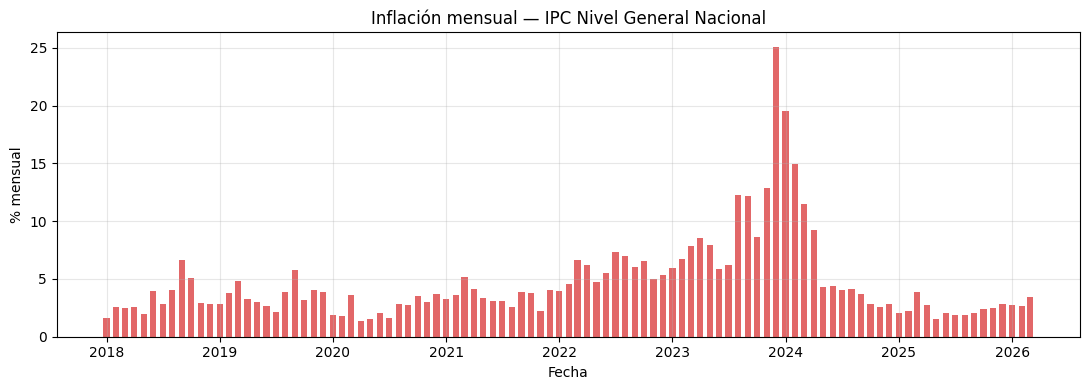

In [4]:
datos = df[df["fecha"] >= "2018-01-01"]   # filtramos desde 2018 para no sobrecargar el gráfico

plt.figure(figsize=(11, 4))
plt.bar(datos["fecha"], datos["inflacion_mensual"], width=20, color="tab:red", alpha=0.7)  # una barra por mes
plt.axhline(0, color="black", linewidth=0.5)   # línea de referencia en cero
plt.title("Inflación mensual — IPC Nivel General Nacional")
plt.xlabel("Fecha"); plt.ylabel("% mensual")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

Este gráfico es la **función marginal**: cada barra es la tasa de cambio del mes. Es lo equivalente al CMg de la teoría — un *flujo* mes a mes.

## 4. Inflación acumulada en un período (la "función total")

Para acumular tasas porcentuales **NO** se suman: se multiplican los factores `(1 + π_t)`. Esto es porque cada mes la inflación se aplica sobre el nivel de precios *del mes anterior*, no sobre el inicial.

$$\text{Inflación acumulada}(0 \to T) = \prod_{t=1}^{T} (1 + \pi_t) - 1$$

La Π grande significa *"multiplicar esto para cada mes"*. En vez de sumar los porcentajes, multiplicás los **factores** de cada mes.

**Ejemplo:** si en enero subió 10% y en febrero 20%:
- Factor enero = 1 + 0.10 = **1.10**
- Factor febrero = 1 + 0.20 = **1.20**
- Acumulada = 1.10 × 1.20 − 1 = 1.32 − 1 = **32%**

Si los sumaras ingenuamente darías 30% — esos 2 puntos de diferencia son el **efecto compuesto**.

---

La forma más práctica es usar directamente el cociente de IPCs:

$$\text{Inflación acumulada}(t_0 \to t_1) = \frac{IPC_{t_1}}{IPC_{t_0}} - 1$$

Dividís el IPC del mes final por el del mes inicial y le restás 1. Da exactamente el mismo resultado que la fórmula anterior, pero sin necesitar todos los valores intermedios.

**Ejemplo 2024:**
- IPC diciembre 2023 = 3.717
- IPC diciembre 2024 = 8.254
- Acumulada = 8.254 / 3.717 − 1 = **122%**

> El **−1** en ambas fórmulas convierte el cociente en una variación. Sin él, el resultado sería "cuántas veces más caro" (2.22×), no "cuánto aumentó en porcentaje" (122%).

In [5]:
def inflacion_acumulada(fecha_ini, fecha_fin):
    """Inflación acumulada entre dos fechas ('YYYY-MM-DD').
    Equivale a preguntar: ¿cuánto subieron los precios desde fecha_ini hasta fecha_fin?"""
    ipc = df.set_index("fecha")["ipc"]   # indexamos por fecha para acceder directo por nombre
    # Fórmula del odómetro: (IPC_final / IPC_inicial − 1) × 100
    return (ipc[pd.to_datetime(fecha_fin)] / ipc[pd.to_datetime(fecha_ini)] - 1) * 100

print(f"Inflación acumulada 2023: {inflacion_acumulada('2022-12-01', '2023-12-01'):.1f}%")
print(f"Inflación acumulada 2024: {inflacion_acumulada('2023-12-01', '2024-12-01'):.1f}%")

Inflación acumulada 2023: 210.1%
Inflación acumulada 2024: 122.1%


## 5. Trampa clásica: la inflación NO se suma

Cuando las tasas mensuales son positivas, sumar las inflaciones mensuales suele **subestimar** la acumulada porque ignora el efecto compuesto. Comparemos:

In [ ]:
año2024 = df[(df["fecha"] >= "2024-01-01") & (df["fecha"] <= "2024-12-01")]  # solo los 12 meses de 2024

# Error clásico: sumar los % como si fueran independientes (ignora que cada mes parte del nivel anterior)
suma      = año2024["inflacion_mensual"].sum()

# Forma correcta: multiplicar los factores (1 + tasa_mes) para cada mes y restar 1 al final
# Ejemplo simple: +50% y luego +50% no es 100%, es (1.5 × 1.5 − 1) = 125%
compuesta = ((1 + año2024["inflacion_mensual"] / 100).prod() - 1) * 100

print(f"Suma ingenua:  {suma:.1f}%")
print(f"Compuesta:     {compuesta:.1f}%")
print(f"Diferencia:    {compuesta - suma:.1f} pp")

Suma ingenua:  84.1%
Compuesta:     122.1%
Diferencia:    38.1 pp


Lección: la diferencia no es chica. Y la razón es exactamente la misma por la que en *integrales* las cosas no escalan linealmente cuando hay efectos compuestos: cada período se aplica sobre el nivel acumulado del anterior.

## 6. Visualización: marginal vs acumulada

Mostramos los dos paneles juntos — la marginal (barras) y la acumulada (área). La conexión entre ambas es la idea central del video.

En el panel derecho mostramos la inflación acumulada **efectiva**, es decir, el aumento porcentual total desde enero de 2018. Más abajo conectamos esta idea con logaritmos, que son la forma más limpia de escribir el paralelo con integrales.

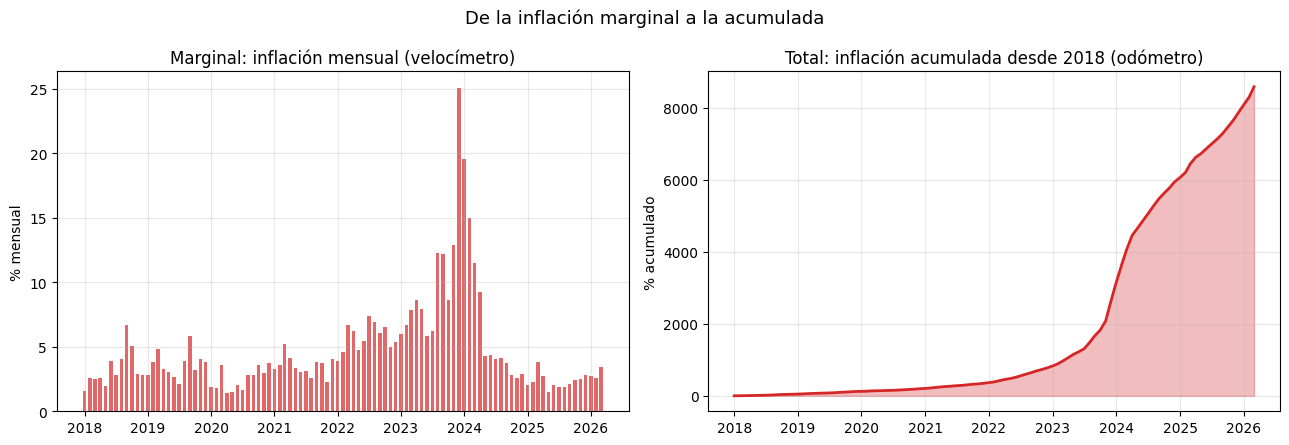

In [7]:
datos = df[df["fecha"] >= "2018-01-01"].copy()
datos["acum"] = (datos["ipc"] / datos["ipc"].iloc[0] - 1) * 100  # acumulada tomando 2018 como origen

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))  # dos paneles lado a lado

# Panel izquierdo: el VELOCÍMETRO — cuánto sube cada mes
ax1.bar(datos["fecha"], datos["inflacion_mensual"], width=20, color="tab:red", alpha=0.7)
ax1.set_title("Marginal: inflación mensual (velocímetro)")
ax1.set_ylabel("% mensual"); ax1.grid(alpha=0.3)

# Panel derecho: el ODÓMETRO — cuánto subió en total desde 2018
ax2.fill_between(datos["fecha"], datos["acum"], color="tab:red", alpha=0.3)  # área bajo la curva
ax2.plot(datos["fecha"], datos["acum"], color="tab:red", linewidth=2)
ax2.set_title("Total: inflación acumulada desde 2018 (odómetro)")
ax2.set_ylabel("% acumulado"); ax2.grid(alpha=0.3)

plt.suptitle("De la inflación marginal a la acumulada", fontsize=13)
plt.tight_layout(); plt.show()

## 7. Conexión con integrales

Si llamamos $\pi(t)$ a la tasa de inflación instantánea (en tiempo continuo), entonces el log del nivel de precios es:

$$ \ln P(T) - \ln P(0) = \int_0^T \pi(t) \, dt $$

Es decir: el área bajo la curva de inflación entre dos momentos es la inflación acumulada **en log** entre ellos. Si queremos volver a una inflación efectiva, usamos:

$$ \text{Inflación efectiva} = e^{\text{inflación log}} - 1 $$

En datos mensuales discretos, el análogo es sumar log-cambios:

$$ \sum_t \ln\left(\frac{IPC_t}{IPC_{t-1}}\right) = \ln\left(\frac{IPC_T}{IPC_0}\right) $$

Esto es el **paralelo perfecto** con lo que vimos en los videos anteriores:

| Teoría | Ejemplo de hoy |
|---|---|
| Costo marginal $CMg(q)$ | Inflación mensual $\pi_t$ |
| Costo total $C(q) = \int CMg \, dq$ | Log del nivel de precios $\ln P_t$ (acumulando $\pi_t$) |
| Constante de integración = costo fijo | Constante = nivel de precios inicial $P_0$ |

**Misma idea, otro contexto.** La inflación mensual te da el ritmo; integrar o acumular esos cambios te permite recuperar la variación total del nivel de precios.

## Cierre

Lo que vimos en este caso:

1. La inflación mensual del INDEC es una variable **marginal** — mide *el cambio* mes a mes.
2. Para obtener la inflación **acumulada** en un período, hay que acumular esos cambios marginales — que en tiempo continuo es **integrar**.
3. La trampa clásica de **sumar** las inflaciones mensuales puede distorsionar la acumulada porque ignora el efecto compuesto.
4. La idea es idéntica a lo que vimos con costos marginales: la **integral acumula los cambios marginales**.

Ahí está el puente entre la teoría de los videos 1 a 3 y los datos reales que sale en los diarios todos los meses.